PROJECT NAME - Mind Matters: Exploring Mental Health in Modern Workplaces (EDA)

SUMMARY - 
Mental health has become a critical concern in today's workforce, especially in the technology and corporate sectors. This project explores mental health awareness and treatment patterns among working professionals using data from a global mental health survey. The analysis uses exploratory data analysis (EDA) techniques to uncover patterns, perceptions, and influencing factors around mental health treatment, stigma, and employer support.
The project is designed not to build predictive models but to derive insights from self-reported survey data and present trends that could inform workplace mental health policies.

Dataset Overview:
The dataset contained 1,259 responses across 27 features. Key variables included age, gender, country, work interference, treatment history, family history of mental illness, and employer support (benefits, care options, leave policies).

Initial cleaning steps:
Age filtering: Unrealistic ages (<15 or >80) were removed.
Gender normalization: Values like "M", "male", "Malr" were standardized to "Male", and similar steps were taken for "Female".
Missing values: Columns like self_employed and work_interfere had missing entries, which were filled with "Don't know" or appropriate placeholders to retain rows for analysis.

Key Findings & Visual Insights:
1. Age Distribution
The highest concentration of respondents fell between the 26–35 age range. This group also showed the highest proportion of individuals who had sought mental health treatment.
2. Gender vs Treatment
After cleaning the gender data:
Males were the most represented group.
Females were relatively more likely to seek treatment than males, revealing potential gender-based differences in openness or mental health awareness.
3. Remote Work & Treatment
Interestingly, individuals who worked remotely were less likely to seek treatment compared to those working onsite. This could point to reduced social interaction, lower visibility of symptoms, or possibly fewer employer interventions in remote setups.
4. Employer Support & Benefits
Respondents whose employers provided mental health benefits or care options were significantly more likely to seek treatment. Lack of support systems correlated with lower treatment rates, emphasizing the importance of workplace mental health infrastructure.
5. Family History & Work Interference
As expected, respondents with a family history of mental illness were more likely to seek help. Also, those who reported that mental health interfered with their work (even occasionally) had higher treatment-seeking behavior.
6. Country-Wise Breakdown
Countries with the highest number of responses included the United States, United Kingdom, Canada, and India. The US had the highest reported treatment rates, possibly due to better access or awareness, while India and other countries showed mixed patterns depending on workplace culture.
7. Communication with Supervisors
Those comfortable discussing mental health issues with their supervisors were more likely to have received treatment. A clear link emerged between psychological safety at work and openness to seek help.

PROBLEM STATEMENT - To identify key trends and barriers affecting mental health support and treatment among working professionals through exploratory data analysis.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [54]:
df= pd.read_csv('survey.csv')

In [55]:
df.shape

(1259, 27)

In [20]:
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [6]:
df.tail()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
1254,2015-09-12 11:17:21,26,male,United Kingdom,NaN,No,No,Yes,NaN,26-100,...,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,No,NaN
1255,2015-09-26 01:07:35,32,Male,United States,IL,No,Yes,Yes,Often,26-100,...,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No,NaN
1256,2015-11-07 12:36:58,34,male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,...,Somewhat difficult,Yes,Yes,No,No,No,No,No,No,NaN
1257,2015-11-30 21:25:06,46,f,United States,NC,No,No,No,NaN,100-500,...,Don't know,Yes,No,No,No,No,No,No,No,NaN
1258,2016-02-01 23:04:31,25,Male,United States,IL,No,Yes,Yes,Sometimes,26-100,...,Don't know,Maybe,No,Some of them,No,No,No,Don't know,No,NaN


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [8]:
df.drop(['state','comments'], axis=1, inplace= True)

In [56]:
def clean_gender(g):
    g = g.strip().lower()
    if g in ['male', 'm', 'man', 'cis male', 'male-ish', 'malr', 'mail']:
        return 'Male'
    elif g in ['female', 'f', 'woman', 'cis female', 'femake']:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)


In [57]:
df["self_employed"] = df["self_employed"].fillna("Don't know") 

In [58]:
df["work_interfere"] = df["work_interfere"].fillna("Don't know")

In [59]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [34]:
df =  df[(df['Age'] >= 10) & (df['Age'] <= 100)]

In [3]:
df.describe(include='all')

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
count,1259,1.259000e+03,1259,1259,744,1241,1259,1259,995,1259,...,1259,1259,1259,1259,1259,1259,1259,1259,1259,164
unique,1246,NaN,49,48,45,2,2,2,4,6,...,5,3,3,3,3,3,3,3,2,160
top,2014-08-27 12:43:28,NaN,Male,United States,CA,No,No,Yes,Sometimes,6-25,...,Don't know,No,No,Some of them,Yes,No,Maybe,Don't know,No,* Small family business - YMMV.
freq,2,NaN,615,751,138,1095,767,637,465,290,...,563,490,925,774,516,1008,557,576,1075,5
mean,NaN,7.942815e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,2.818299e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,-1.726000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2.700000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,3.100000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,3.600000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df['Country'] = df['Country'].str.strip()

In [31]:
country_treatment = df.groupby('Country')['treatment'].value_counts(normalize=True).unstack().fillna(0)
country_treatment = country_treatment.sort_values('Yes', ascending=False).head(10)
country_treatment

treatment,No,Yes
Country,,
"Bahamas, The",0.000000,1.000000
Croatia,0.000000,1.000000
Denmark,0.000000,1.000000
Moldova,0.000000,1.000000
Slovenia,0.000000,1.000000
Zimbabwe,0.000000,1.000000
Japan,0.000000,1.000000
South Africa,0.333333,0.666667
New Zealand,0.375000,0.625000


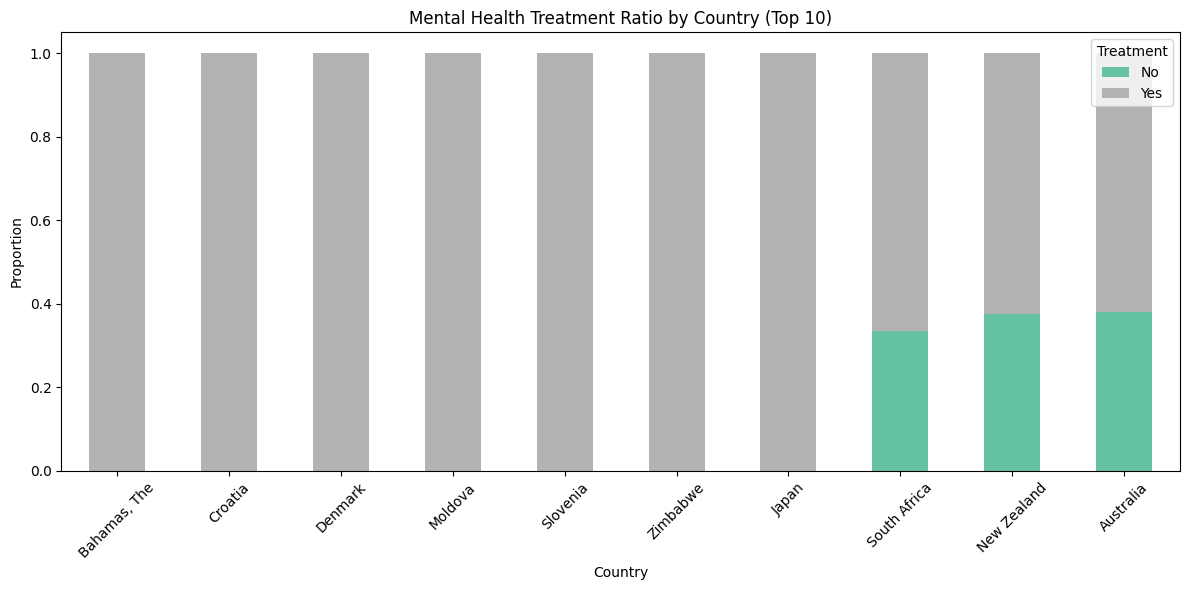

In [60]:
country_treatment.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set2')
plt.title("Mental Health Treatment Ratio by Country (Top 10)")
plt.ylabel("Proportion")
plt.xlabel("Country")
plt.legend(title="Treatment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [61]:
# Get the top 5 countries by response count
top_countries = df['Country'].value_counts().head(5).index

In [62]:
# Filter only those countries
df_top = df[df['Country'].isin(top_countries)]

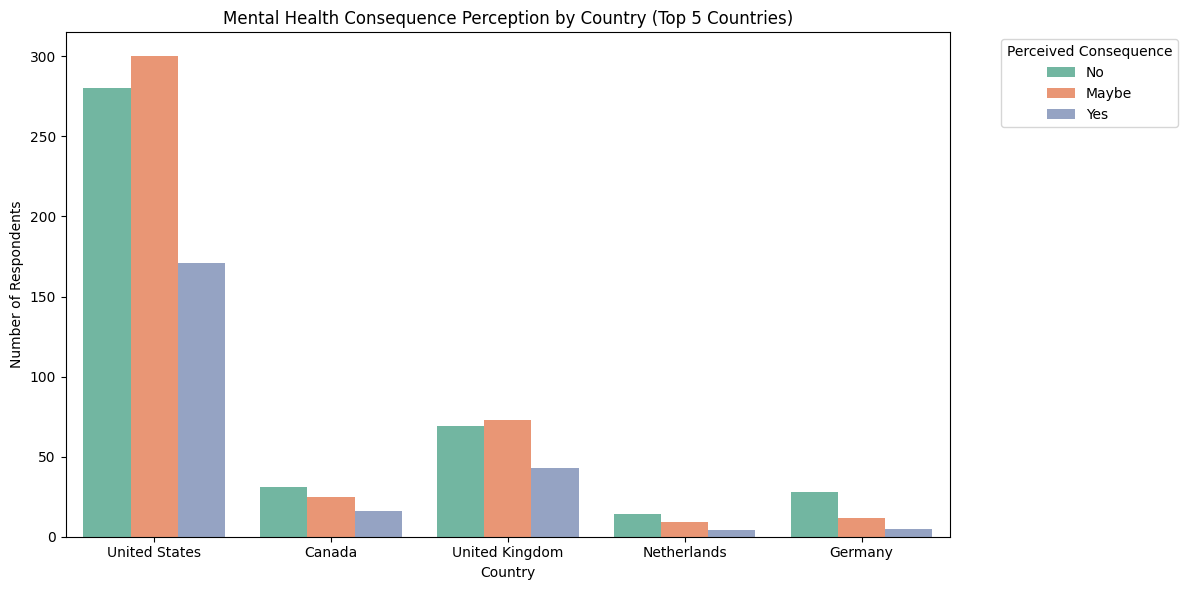

In [38]:
# Plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df_top, x='Country', hue='mental_health_consequence', palette='Set2')

plt.title('Mental Health Consequence Perception by Country (Top 5 Countries)')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.legend(title='Perceived Consequence', bbox_to_anchor=(
    .05, 1), loc='upper left')
plt.tight_layout()
plt.show()

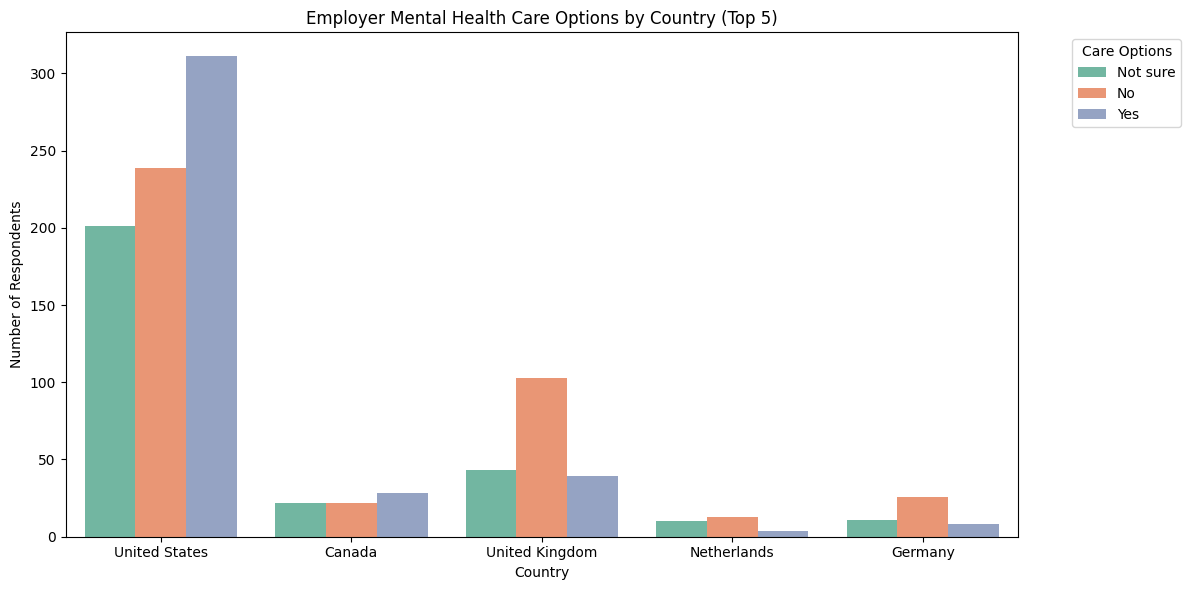

In [63]:
# Plot care options by country
plt.figure(figsize=(12, 6))
sns.countplot(data=df_top, x='Country', hue='care_options', palette='Set2')

plt.title('Employer Mental Health Care Options by Country (Top 5)')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.legend(title='Care Options', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

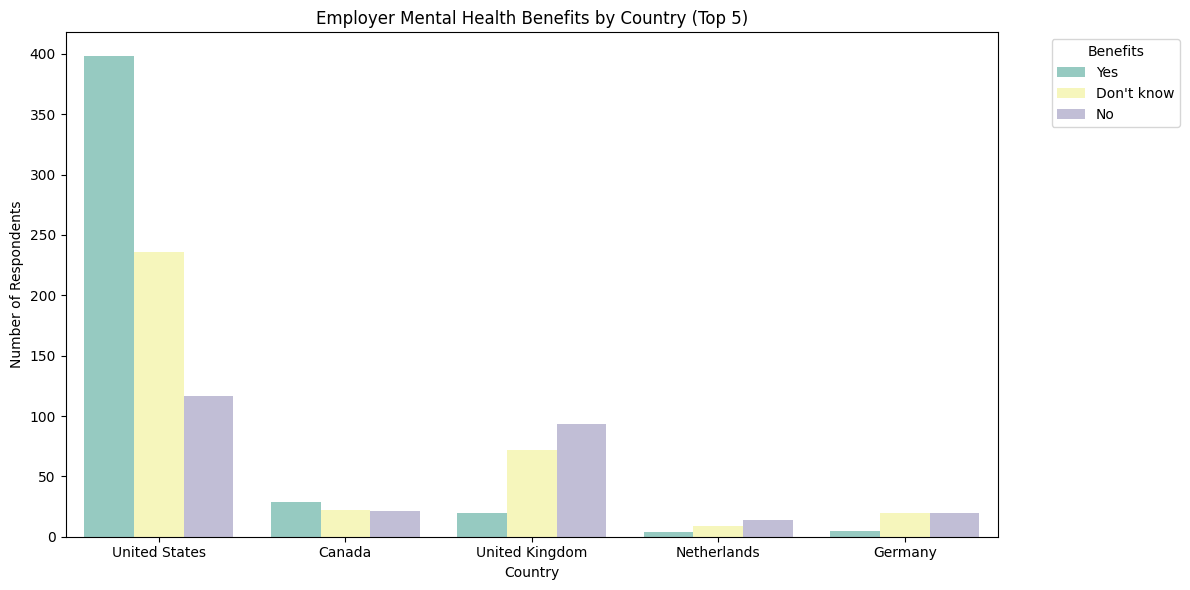

In [64]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_top, x='Country', hue='benefits', palette='Set3')
plt.title('Employer Mental Health Benefits by Country (Top 5)')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.legend(title='Benefits', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

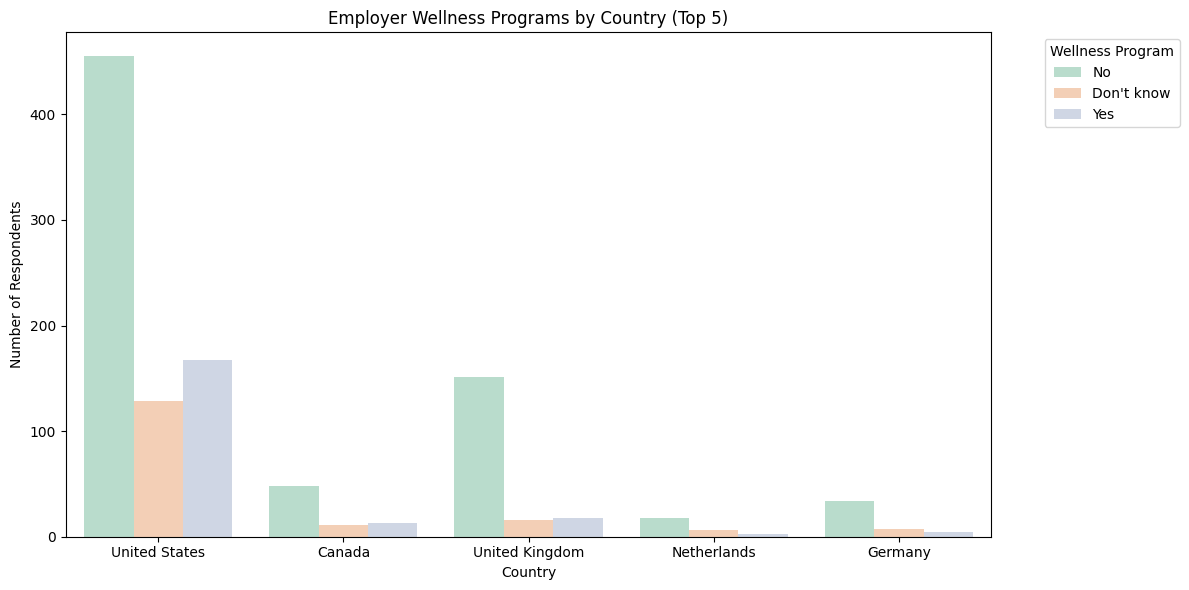

In [65]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_top, x='Country', hue='wellness_program', palette='Pastel2')
plt.title('Employer Wellness Programs by Country (Top 5)')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.legend(title='Wellness Program', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

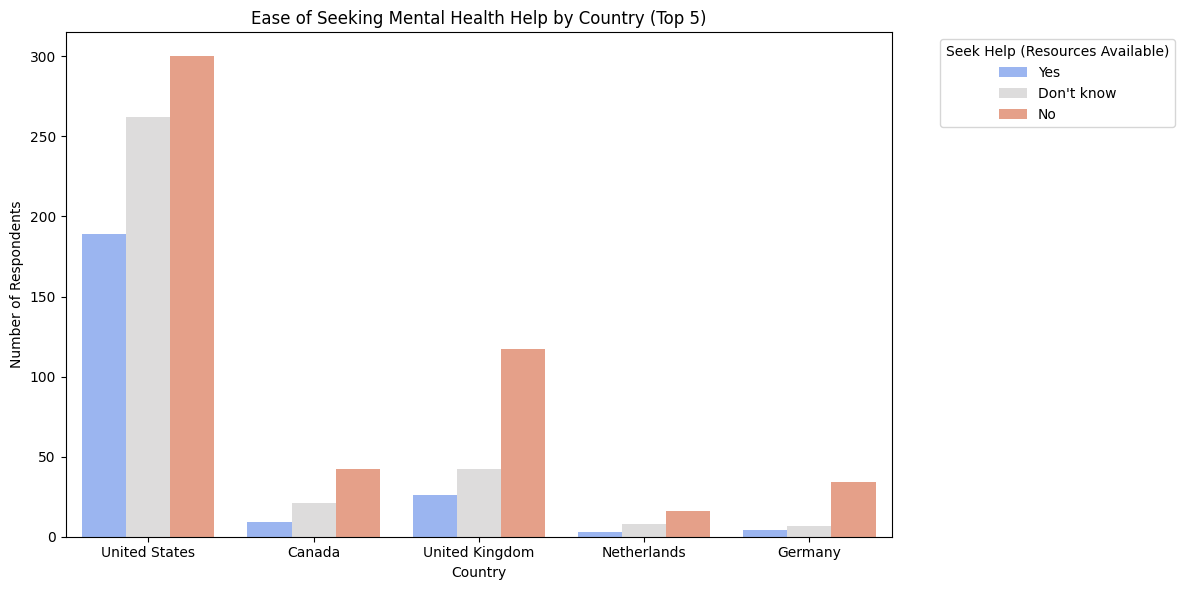

In [66]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_top, x='Country', hue='seek_help', palette='coolwarm')
plt.title('Ease of Seeking Mental Health Help by Country (Top 5)')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.legend(title='Seek Help (Resources Available)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [43]:
# What are the strongest predictors of mental health illness or certain attitudes towards mental health in the workplace?

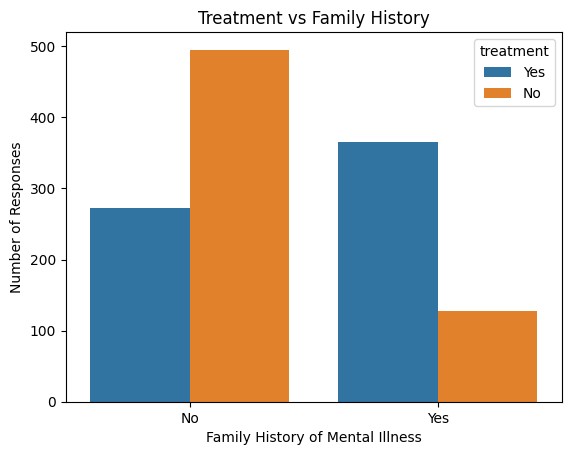

In [67]:
# Treatment rate by family history
sns.countplot(data=df, x='family_history', hue='treatment')
plt.title("Treatment vs Family History")
plt.xlabel("Family History of Mental Illness")
plt.ylabel("Number of Responses")
plt.show()

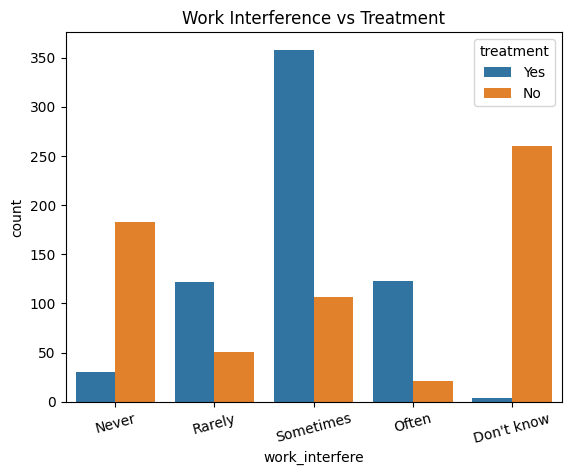

In [68]:
# Work interference and treatment
sns.countplot(data=df, x='work_interfere', hue='treatment', order=['Never','Rarely','Sometimes','Often',"Don't know"])
plt.title("Work Interference vs Treatment")
plt.xticks(rotation=15)
plt.show()

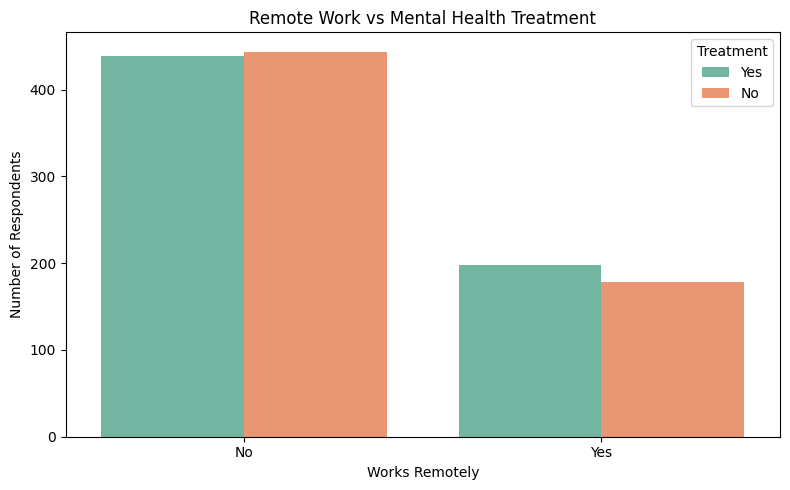

In [92]:
# Remote work vs treatment
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='remote_work', hue='treatment', palette='Set2')
plt.title('Remote Work vs Mental Health Treatment')
plt.xlabel('Works Remotely')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment')
plt.tight_layout()
plt.show()

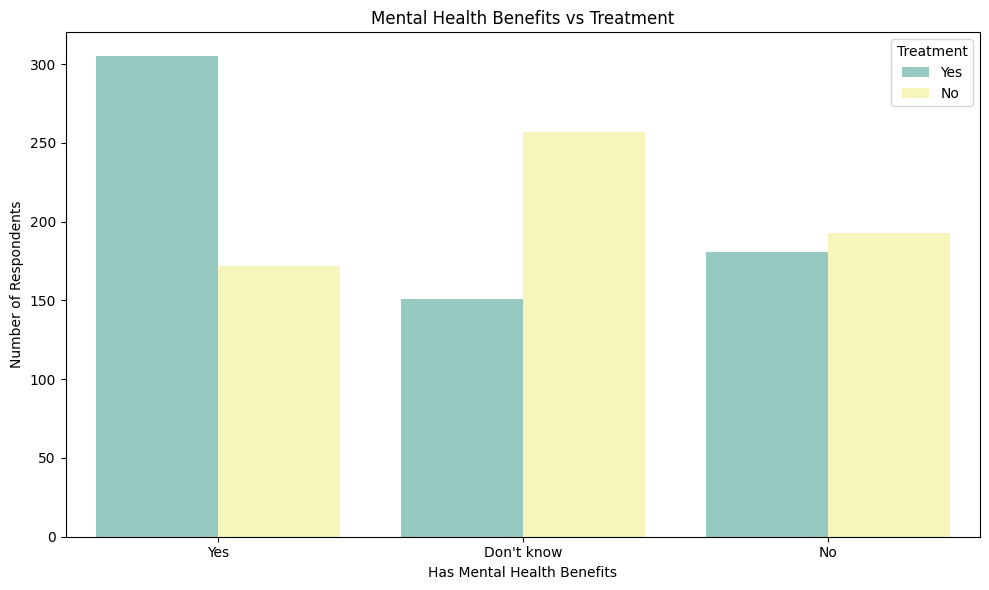

In [70]:
# Benefits vs treatment
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='benefits', hue='treatment', palette='Set3')
plt.title('Mental Health Benefits vs Treatment')
plt.xlabel('Has Mental Health Benefits')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

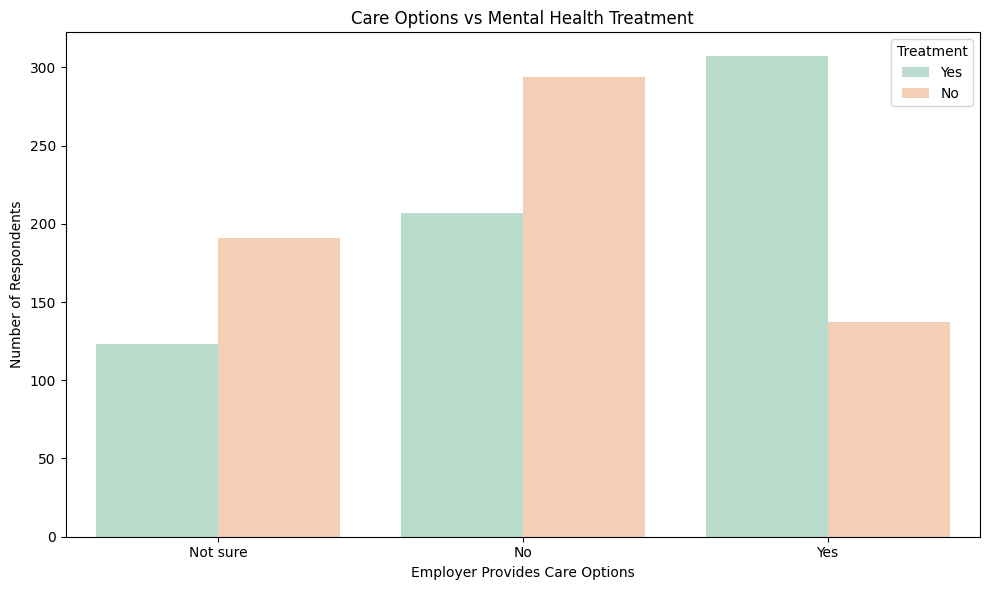

In [71]:
#Care options vs treatment
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='care_options', hue='treatment', palette='Pastel2')
plt.title('Care Options vs Mental Health Treatment')
plt.xlabel('Employer Provides Care Options')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

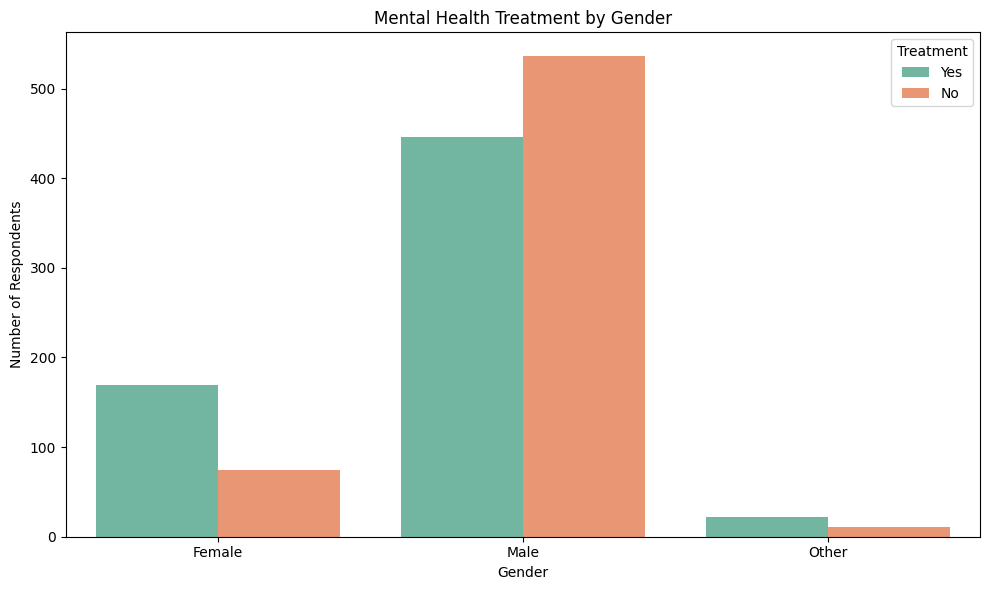

In [73]:
#Gender vs Treatment
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Gender', hue='treatment', palette='Set2')
plt.title('Mental Health Treatment by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [78]:
# Which age groups are more likely to seek mental health treatment?

In [76]:
#Create age bins
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

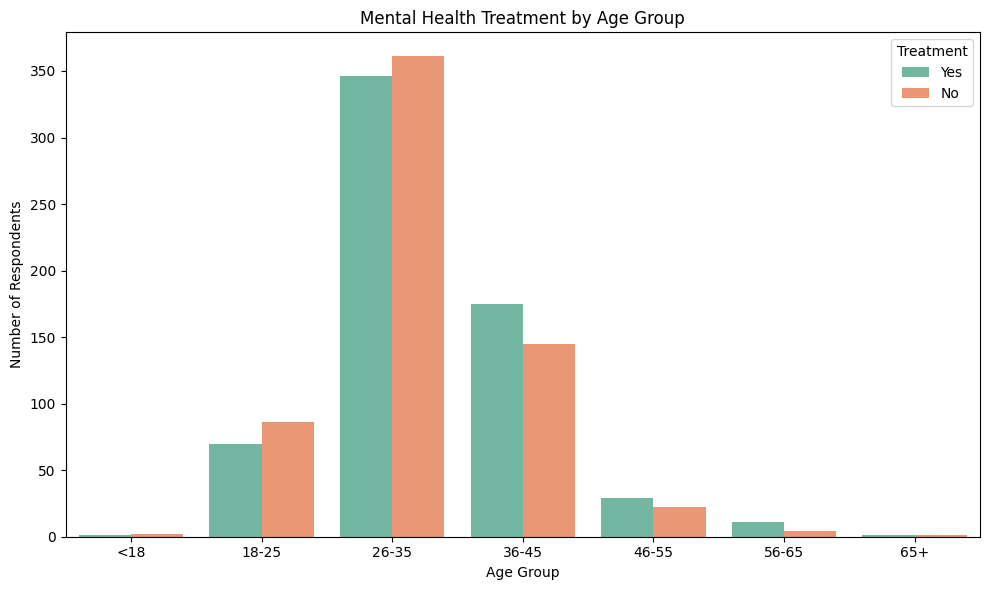

In [77]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Age Group', hue='treatment', palette='Set2')
plt.title('Mental Health Treatment by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment')
plt.tight_layout()
plt.show()

In [81]:
# What do people believe would be the consequence of discussing a mental health issue with their employer?

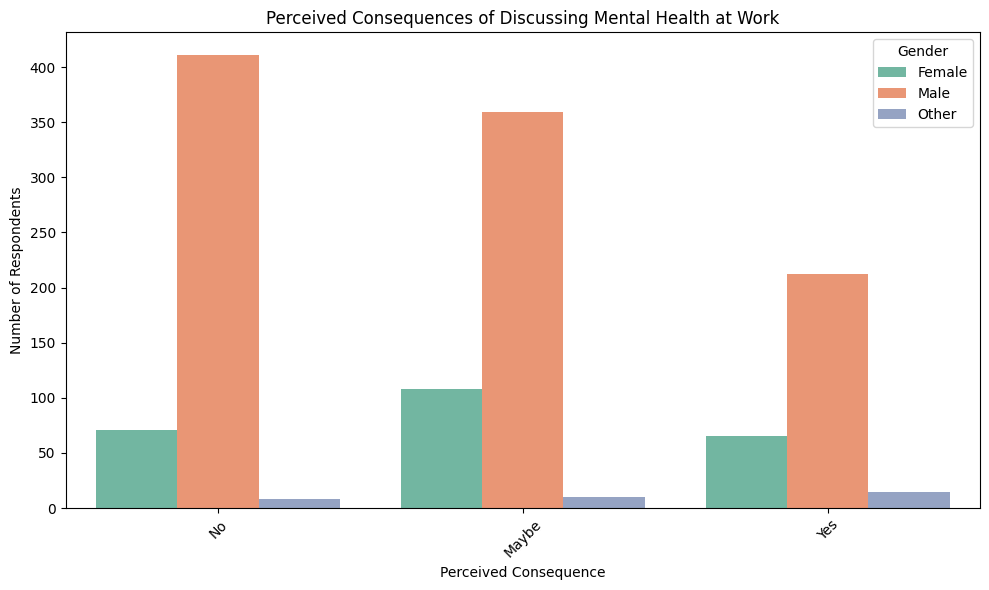

In [82]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='mental_health_consequence', order=df['mental_health_consequence'].value_counts().index, hue= 'Gender', palette='Set2')

plt.title('Perceived Consequences of Discussing Mental Health at Work')
plt.xlabel('Perceived Consequence')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [83]:
# Are employees comfortable discussing mental health issues with their supervisors?

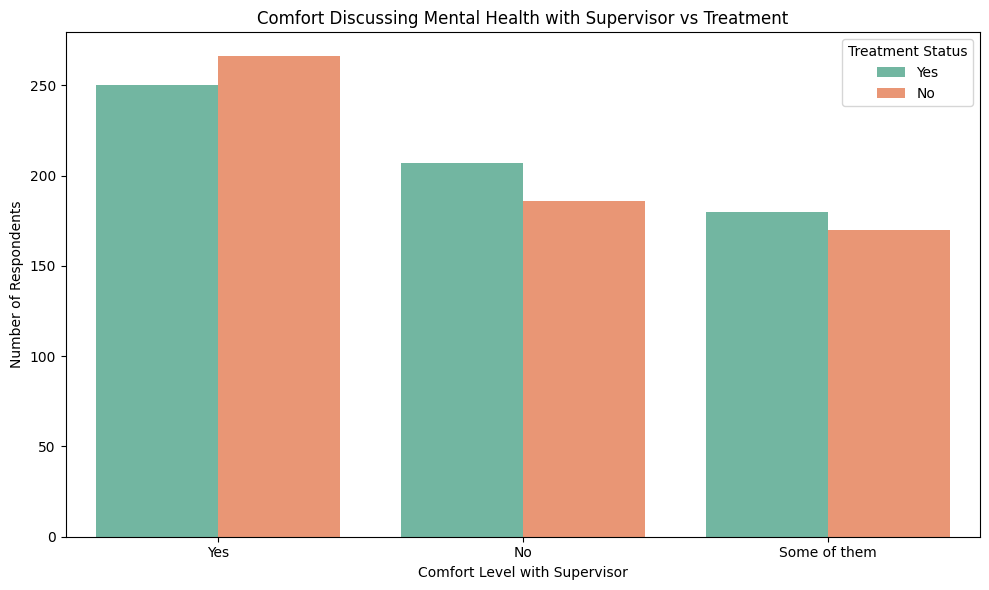

In [84]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='supervisor', hue='treatment', palette='Set2')
plt.title('Comfort Discussing Mental Health with Supervisor vs Treatment')
plt.xlabel('Comfort Level with Supervisor')
plt.ylabel('Number of Respondents')
plt.legend(title='Treatment Status')
plt.tight_layout()
plt.show()

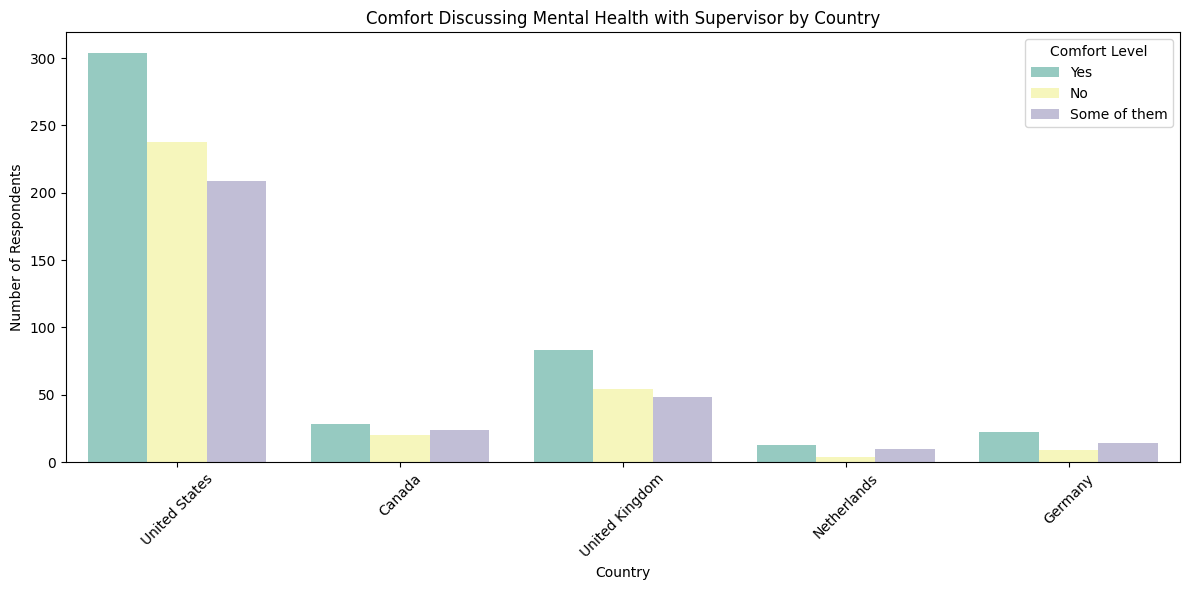

In [85]:
# Comfort level vs country
plt.figure(figsize=(12, 6))
sns.countplot(data=df_top, x='Country', hue='supervisor', palette='Set3')
plt.title('Comfort Discussing Mental Health with Supervisor by Country')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.legend(title='Comfort Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

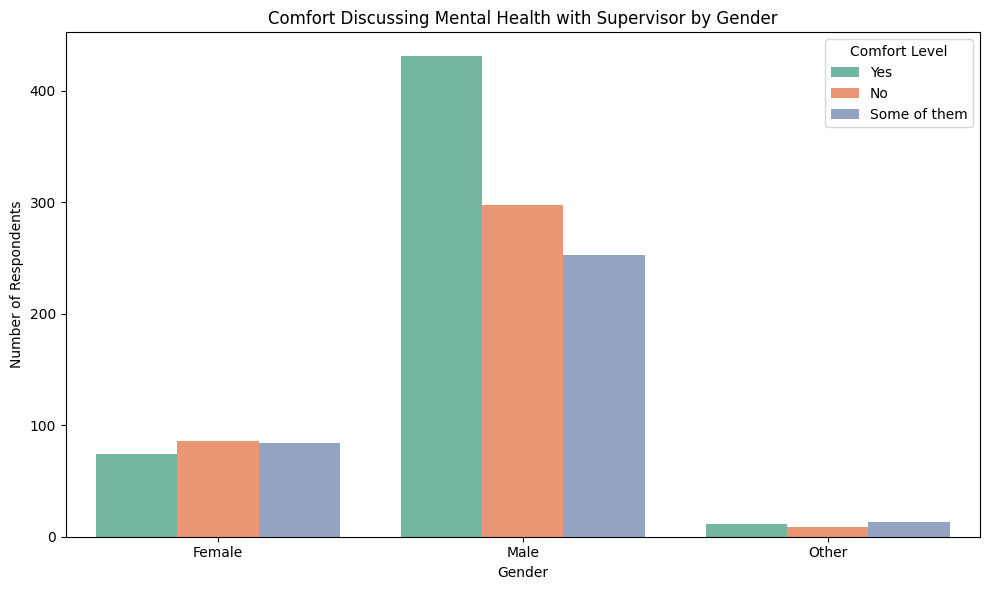

In [86]:
#Comfort level vs Gender
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Gender', hue='supervisor', palette='Set2')
plt.title('Comfort Discussing Mental Health with Supervisor by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Respondents')
plt.legend(title='Comfort Level')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [91]:
# Proportion of respondents from each country and how they answered the “supervisor” question
pd.crosstab(df['Country'], df['supervisor'], normalize='index').round(2).head(10)

supervisor,No,Some of them,Yes
Country,,,
Australia,0.33,0.14,0.52
Austria,0.00,0.67,0.33
"Bahamas, The",0.00,0.00,1.00
Belgium,0.67,0.17,0.17
Bosnia and Herzegovina,1.00,0.00,0.00
Brazil,0.00,0.33,0.67
Bulgaria,0.25,0.50,0.25
Canada,0.28,0.33,0.39
China,0.00,1.00,0.00


SOLUTION -
Recommendations:
1. Raise awareness through workshops.
2. Offer clear mental health support and benefits.
3. Support remote workers with virtual care.
4. Train managers to talk openly about mental health.
5. Encourage balance with flexible policies.
6. Adapt to regions with culturally sensitive programs.
7. Watch for early signs via regular check-ins.

CONCLUSION- 
This EDA project effectively highlights the role of age, gender, employer support, and workplace environment in shaping how employees deal with mental health challenges. It provides strong visual evidence that fostering a supportive and stigma-free workplace can significantly influence treatment-seeking behavior.
By using thoughtful visualizations and a clean analytical approach, this project opens up conversations about how policy-makers, HR leaders, and managers can tailor interventions to create more mentally healthy workplaces.